# CMIP6 Climate Scenarios
Compare SSP1-2.6 / SSP2-4.5 / SSP5-8.5 across four indicators: greenhouse gas (CO₂) concentration, temperature anomaly, precipitation anomaly, and sea level rise.

## Setup

In [10]:
import os, certifi
os.environ.setdefault('SSL_CERT_FILE', certifi.where())
os.environ.setdefault('REQUESTS_CA_BUNDLE', certifi.where())

import json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import gcsfs
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.15)

COLORS = {'ssp126': '#2196F3', 'ssp245': '#FF9800', 'ssp585': '#E53935'}
LABELS = {'ssp126': 'SSP1-2.6  (Low)', 'ssp245': 'SSP2-4.5  (Medium)', 'ssp585': 'SSP5-8.5  (High)'}
HIST_COLOR = '#78909C'

gcs = gcsfs.GCSFileSystem(token='anon')
print('Setup complete')

Setup complete


## Getting Data

### Temperature & Precipitation (from computed JSON)

In [11]:
with open('data/tas_anomalies.json') as f:
    tas_raw = json.load(f)
with open('data/pr_anomalies.json') as f:
    pr_raw = json.load(f)

def global_mean(data):
    """Average country anomalies into a global mean series per scenario."""
    out = {}
    for scen in ['ssp126', 'ssp245', 'ssp585']:
        frames = []
        for cdata in data['regions'].values():
            if scen in cdata:
                frames.append(pd.DataFrame(cdata[scen]).set_index('year')['anomaly'])
        if frames:
            out[scen] = pd.concat(frames, axis=1).mean(axis=1)
    return out

tas_g = global_mean(tas_raw)
pr_g  = global_mean(pr_raw)

def split_hist_future(s):
    return s.loc[:2014], s.loc[2015:]

print('Temperature range:', tas_g['ssp585'].index[0], '-', tas_g['ssp585'].index[-1])
print('Countries averaged:', sum(1 for c in tas_raw['regions'].values() if 'ssp245' in c))

Temperature range: 1980 - 2100
Countries averaged: 153


### CO₂ Concentration (RCMIP public concentrations dataset)

In [12]:
RCMIP_URL = ('https://rcmip-protocols-au.s3-ap-southeast-2.amazonaws.com'
             '/v5.1.0/rcmip-concentrations-annual-means-v5-1-0.csv')
print('Downloading RCMIP concentrations (~5 MB)...')
rcmip = pd.read_csv(RCMIP_URL, low_memory=False)

year_cols = [c for c in rcmip.columns if c.isdigit()]

def get_co2(scenario_str):
    mask = (
        rcmip['Variable'].str.lower().str.startswith('atmospheric concentrations|co2') &
        rcmip['Region'].str.lower().str.contains('world') &
        rcmip['Scenario'].str.lower().str.contains(scenario_str.lower())
    )
    sub = rcmip[mask]
    if sub.empty:
        return None
    row = sub.iloc[0]
    s = pd.to_numeric(pd.Series(row[year_cols].values, index=[int(y) for y in year_cols]), errors='coerce')
    return s.loc[1980:2100].dropna()

co2 = {scen: get_co2(scen) for scen in ['ssp126', 'ssp245', 'ssp585', 'historical']}
for k, v in co2.items():
    if v is not None:
        print(f'  {k}: {v.index[0]}-{v.index[-1]}, {v.min():.0f}-{v.max():.0f} ppm')

  ssp126: 1980-2100, 339-474 ppm
  ssp245: 1980-2100, 339-603 ppm
  ssp585: 1980-2100, 339-1135 ppm
  historical: 1980-2014, 339-398 ppm


### Sea Level Rise (zostoga from CMIP6)

In [13]:
CATALOG_CSV = 'https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv'
print('Loading catalog...')
cat = pd.read_csv(CATALOG_CSV)

PRIMARY_MODEL  = 'MPI-ESM1-2-LR'
FALLBACK_MODEL = 'CESM2'

def find_zostoga(experiment):
    for model in [PRIMARY_MODEL, FALLBACK_MODEL]:
        sub = cat.query(f"variable_id=='zostoga' & experiment_id=='{experiment}' & source_id=='{model}' & table_id=='Omon'")
        if not sub.empty:
            print(f'  {experiment}: {model}')
            return sub.iloc[0].zstore
    print(f'  {experiment}: not found')
    return None

def load_sl(zstore):
    mapper = gcs.get_mapper(zstore)
    ds = xr.open_zarr(mapper, consolidated=True)
    da = ds['zostoga'].sortby('time') * 100   # m → cm
    return da.resample(time='YE').mean().load()

zstore_hist = find_zostoga('historical')
sl_hist_raw = load_sl(zstore_hist) if zstore_hist else None

sl_hist, sl_scen = {}, {}
if sl_hist_raw is not None:
    bl_sl = float(sl_hist_raw.sel(time=slice('1995','2014')).mean().values)
    for scen in ['ssp126', 'ssp245', 'ssp585']:
        zs = find_zostoga(scen)
        if zs is None:
            continue
        sl_s = load_sl(zs)
        sl_hist[scen] = pd.Series(
            (sl_hist_raw.sel(time=slice('1980','2014')) - bl_sl).values,
            index=sl_hist_raw.sel(time=slice('1980','2014'))['time'].dt.year.values)
        sl_scen[scen] = pd.Series(
            (sl_s.sel(time=slice('2015','2100')) - bl_sl).values,
            index=sl_s.sel(time=slice('2015','2100'))['time'].dt.year.values)
        print(f'  {scen} 2100: {sl_scen[scen].iloc[-1]:.1f} cm')

Loading catalog...
  historical: MPI-ESM1-2-LR
  ssp126: MPI-ESM1-2-LR
  ssp126 2100: 13.7 cm
  ssp245: MPI-ESM1-2-LR
  ssp245 2100: 19.3 cm
  ssp585: MPI-ESM1-2-LR
  ssp585 2100: 28.3 cm


## Climate Indicator Charts

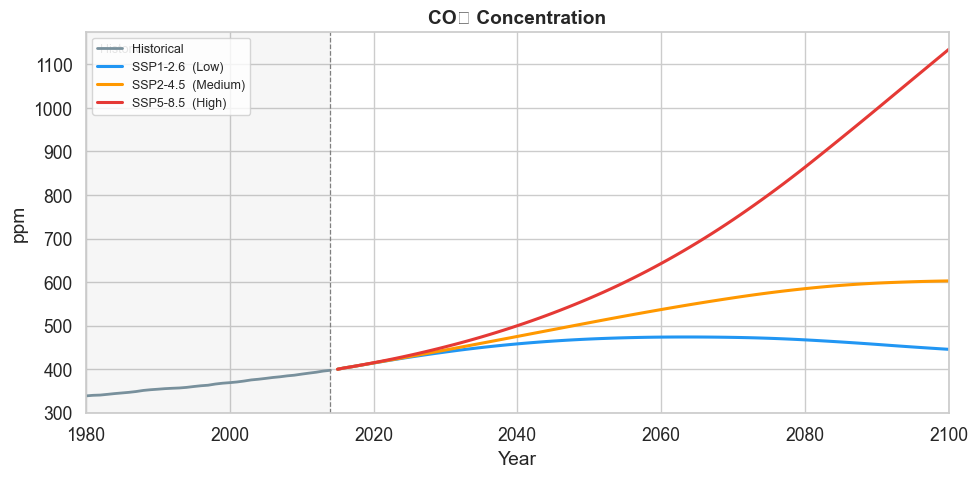

Saved → data/eda_co2.png


In [14]:
def mark_hist(ax, y_frac=0.97):
    ax.axvspan(1980, 2014, alpha=0.07, color='grey')
    ax.axvline(2014, color='grey', lw=0.9, ls='--')
    ylim = ax.get_ylim()
    ax.text(1982, ylim[0] + (ylim[1]-ylim[0])*y_frac, 'Historical', color='grey', fontsize=9, va='top')

fig, ax = plt.subplots(figsize=(10, 5))
if co2['historical'] is not None:
    h = co2['historical'].loc[1980:2014]
    ax.plot(h.index, h, color=HIST_COLOR, lw=2, label='Historical')
for scen in ['ssp126', 'ssp245', 'ssp585']:
    if co2[scen] is not None:
        f = co2[scen].loc[2015:]
        ax.plot(f.index, f, color=COLORS[scen], lw=2.2, label=LABELS[scen])
ax.set_title('CO\u2082 Concentration', fontweight='bold')
ax.set_ylabel('ppm')
ax.set_xlabel('Year')
ax.set_xlim(1980, 2100)
mark_hist(ax)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
os.makedirs('data', exist_ok=True)
plt.savefig('data/eda_co2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved \u2192 data/eda_co2.png')


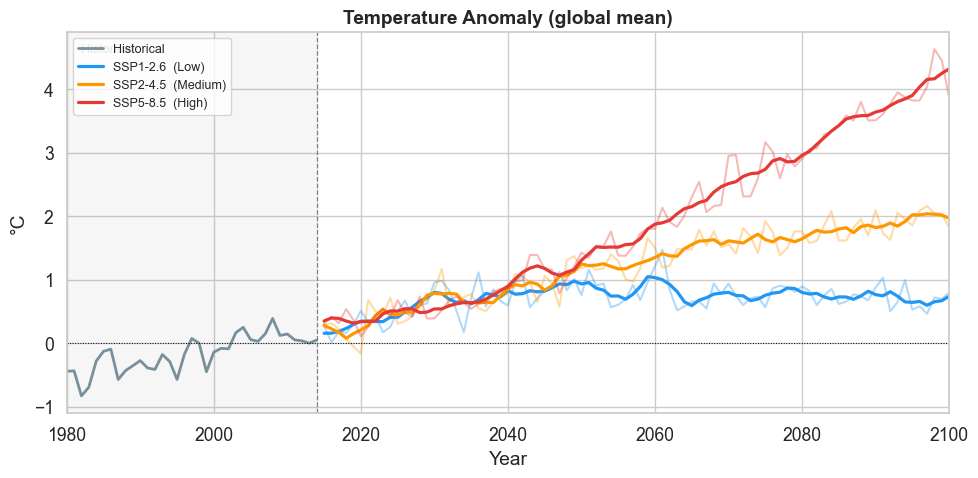

Saved → data/eda_temperature.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
first = True
for scen, series in tas_g.items():
    h, f = split_hist_future(series)
    if first:
        ax.plot(h.index, h, color=HIST_COLOR, lw=2, label='Historical')
        first = False
    ax.plot(f.index, f, color=COLORS[scen], lw=1.5, alpha=0.35)
    ax.plot(f.index, f.rolling(5, center=True, min_periods=1).mean(),
            color=COLORS[scen], lw=2.3, label=LABELS[scen])
ax.axhline(0, color='black', lw=0.7, ls=':')
ax.set_title('Temperature Anomaly (global mean)', fontweight='bold')
ax.set_ylabel('\u00b0C')
ax.set_xlabel('Year')
ax.set_xlim(1980, 2100)
mark_hist(ax)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('data/eda_temperature.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved \u2192 data/eda_temperature.png')


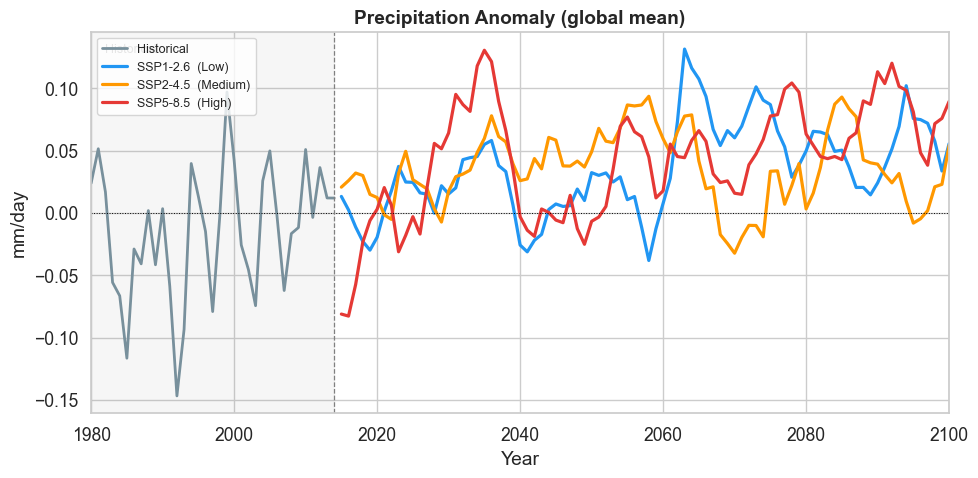

Saved → data/eda_precipitation.png


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
first = True
for scen, series in pr_g.items():
    h, f = split_hist_future(series)
    if first:
        ax.plot(h.index, h, color=HIST_COLOR, lw=2, label='Historical')
        first = False
    ax.plot(f.index, f.rolling(5, center=True, min_periods=1).mean(),
            color=COLORS[scen], lw=2.3, label=LABELS[scen])
ax.axhline(0, color='black', lw=0.7, ls=':')
ax.set_title('Precipitation Anomaly (global mean)', fontweight='bold')
ax.set_ylabel('mm/day')
ax.set_xlabel('Year')
ax.set_xlim(1980, 2100)
mark_hist(ax)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('data/eda_precipitation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved \u2192 data/eda_precipitation.png')


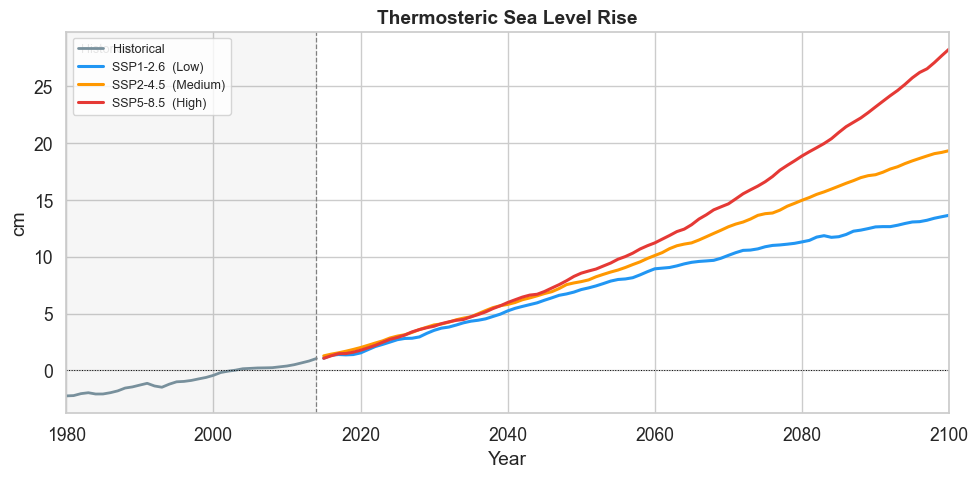

Saved → data/eda_sea_level.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
if sl_hist:
    first = True
    for scen in ['ssp126', 'ssp245', 'ssp585']:
        if scen not in sl_hist:
            continue
        if first:
            ax.plot(sl_hist[scen].index, sl_hist[scen], color=HIST_COLOR, lw=2, label='Historical')
            first = False
        ax.plot(sl_scen[scen].index, sl_scen[scen], color=COLORS[scen], lw=2.2, label=LABELS[scen])
else:
    ax.text(0.5, 0.5, 'zostoga unavailable', ha='center', va='center',
            transform=ax.transAxes, color='grey', fontsize=12)
ax.axhline(0, color='black', lw=0.7, ls=':')
ax.set_title('Thermosteric Sea Level Rise', fontweight='bold')
ax.set_ylabel('cm')
ax.set_xlabel('Year')
ax.set_xlim(1980, 2100)
mark_hist(ax)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('data/eda_sea_level.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved \u2192 data/eda_sea_level.png')


## Scenario Divergence Year

SSP5-8.5 exceeds SSP1-2.6 by >0.5°C from: 2043


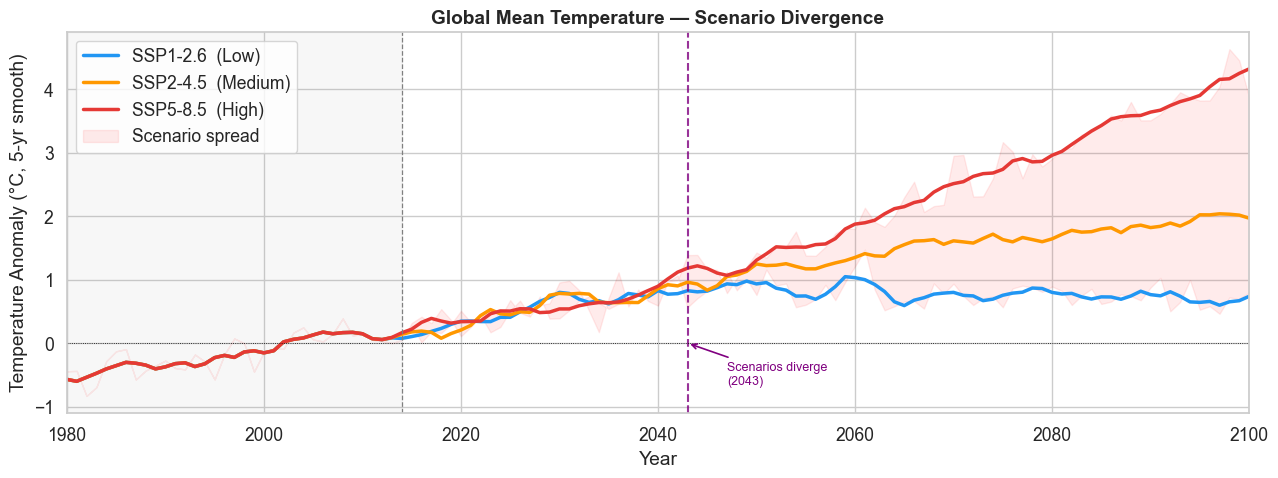

In [18]:
gap = (tas_g['ssp585'] - tas_g['ssp126']).loc[2015:]
div_year = gap[gap > 0.5].index[0] if (gap > 0.5).any() else None
print(f'SSP5-8.5 exceeds SSP1-2.6 by >0.5°C from: {div_year}')

fig, ax = plt.subplots(figsize=(13, 5))
for scen, series in tas_g.items():
    smooth = series.rolling(5, center=True, min_periods=1).mean()
    ax.plot(smooth.index, smooth, color=COLORS[scen], lw=2.5, label=LABELS[scen])

if div_year:
    ax.axvline(div_year, color='purple', lw=1.5, ls='--', alpha=0.8)
    ax.annotate(f'Scenarios diverge\n({div_year})', xy=(div_year, 0),
                xytext=(div_year+4, ax.get_ylim()[0]+0.2),
                color='purple', fontsize=9,
                arrowprops=dict(arrowstyle='->', color='purple', lw=1.2))

ax.fill_between(tas_g['ssp126'].index, tas_g['ssp126'], tas_g['ssp585'],
                alpha=0.08, color='red', label='Scenario spread')
ax.axvspan(1980, 2014, alpha=0.06, color='grey')
ax.axvline(2014, color='grey', lw=0.9, ls='--')
ax.axhline(0, color='black', lw=0.6, ls=':')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature Anomaly (°C, 5-yr smooth)')
ax.set_title('Global Mean Temperature — Scenario Divergence', fontweight='bold')
ax.set_xlim(1980, 2100)
ax.legend()
plt.tight_layout()
plt.savefig('data/eda_divergence.png', dpi=150, bbox_inches='tight')
plt.show()